# ACC102 Track4 Project: Financial Data Analysis Notebook
## Project Introduction
This notebook shows the full Python analysis workflow for the listed company ROE comparison tool, including data loading, cleaning, indicator calculation, visualization and insight generation.

## Data Source
Sample financial data of Apple and Microsoft (2020-2023), accessed on 2026-04-20

In [2]:
# Import required libraries
import pandas as pd
import plotly.express as px

In [3]:
# Load data
df = pd.read_csv("data/finance_data.csv")

# Show the first 5 rows of data
print("Raw Data Preview:")
df.head()

Raw Data Preview:


,company,year,roe,revenue
0,Apple,2020,0.25,274515
1,Apple,2021,0.28,365817
2,Apple,2022,0.30,394328
3,Apple,2023,0.29,383285
4,Microsoft,2020,0.37,143015


In [4]:
# Data cleaning & inspection
# Check missing values
print("Missing Value Check:")
print(df.isnull().sum())

# Check data types
print("\nData Type Check:")
print(df.dtypes)

Missing Value Check:
company    0
year       0
roe        0
revenue    0
dtype: int64

Data Type Check:
company        str
year         int64
roe        float64
revenue      int64
dtype: object


In [5]:
# Calculate core indicators
# Average ROE per company
avg_roe = df.groupby("company")["roe"].mean().sort_values(ascending=False)
print("Average ROE (2020-2023):")
print(avg_roe)

# Year-over-year revenue growth rate
df["revenue_growth"] = df.groupby("company")["revenue"].pct_change() * 100
print("\nRevenue Growth Rate (%):")
print(df)

Average ROE (2020-2023):
company
Microsoft    0.375
Apple        0.280
Name: roe, dtype: float64

Revenue Growth Rate (%):
     company  year   roe  revenue  revenue_growth
0      Apple  2020  0.25   274515             NaN
1      Apple  2021  0.28   365817       33.259385
2      Apple  2022  0.30   394328        7.793788
3      Apple  2023  0.29   383285       -2.800461
4  Microsoft  2020  0.37   143015             NaN
5  Microsoft  2021  0.40   168088       17.531727
6  Microsoft  2022  0.38   198270       17.956071
7  Microsoft  2023  0.35   211915        6.882030


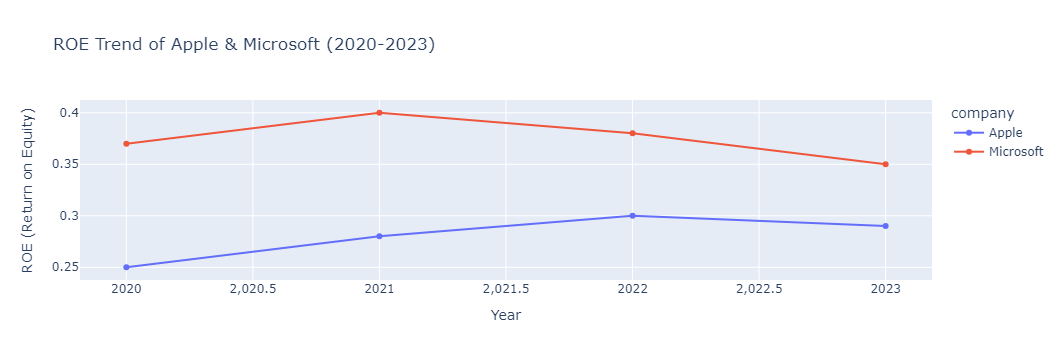

In [6]:
# ROE Trend Visualization
fig_roe = px.line(
    df,
    x="year",
    y="roe",
    color="company",
    markers=True,
    title="ROE Trend of Apple & Microsoft (2020-2023)",
    labels={"roe": "ROE (Return on Equity)", "year": "Year"}
)
fig_roe.show()

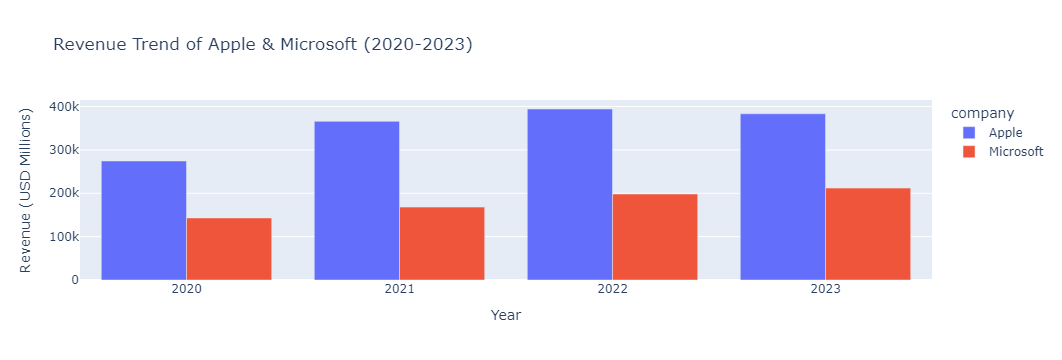

In [7]:
# Revenue Trend Visualization
fig_revenue = px.bar(
    df,
    x="year",
    y="revenue",
    color="company",
    barmode="group",
    title="Revenue Trend of Apple & Microsoft (2020-2023)",
    labels={"revenue": "Revenue (USD Millions)", "year": "Year"}
)
fig_revenue.show()

## Key Insights
1. Microsoft has a higher average ROE than Apple during 2020-2023, indicating stronger profitability in using shareholders' equity.
2. Both companies achieved steady revenue growth from 2020 to 2022, but faced a slight revenue decline in 2023.
3. Apple's ROE showed a continuous upward trend from 2020 to 2022, reflecting improving profitability.

## Limitations
- The dataset only covers two companies, with limited industry representativeness.
- The data is sample data, not real-time updated official financial data.
- Only two core financial indicators are analyzed, without deeper financial health assessment.